# Student Performance Prediction: A Multiple Linear Regression Approach

## 1. Import Libraries and Data Understanding

In [31]:
# Import necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [32]:
# Load the dataset
df = pd.read_csv('student_performance.csv')
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [34]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [35]:
# Check missing values
print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


## 2. Exploratory Data Analysis

In [36]:
eda_data = df.copy()

In [37]:
# map categorical 'Extracurricular Activities' to numerical values for correlation analysis
eda_data['Extracurricular Activities'] = eda_data['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [38]:
# Calculate the correlation matric
correlation_matrix = eda_data.corr()

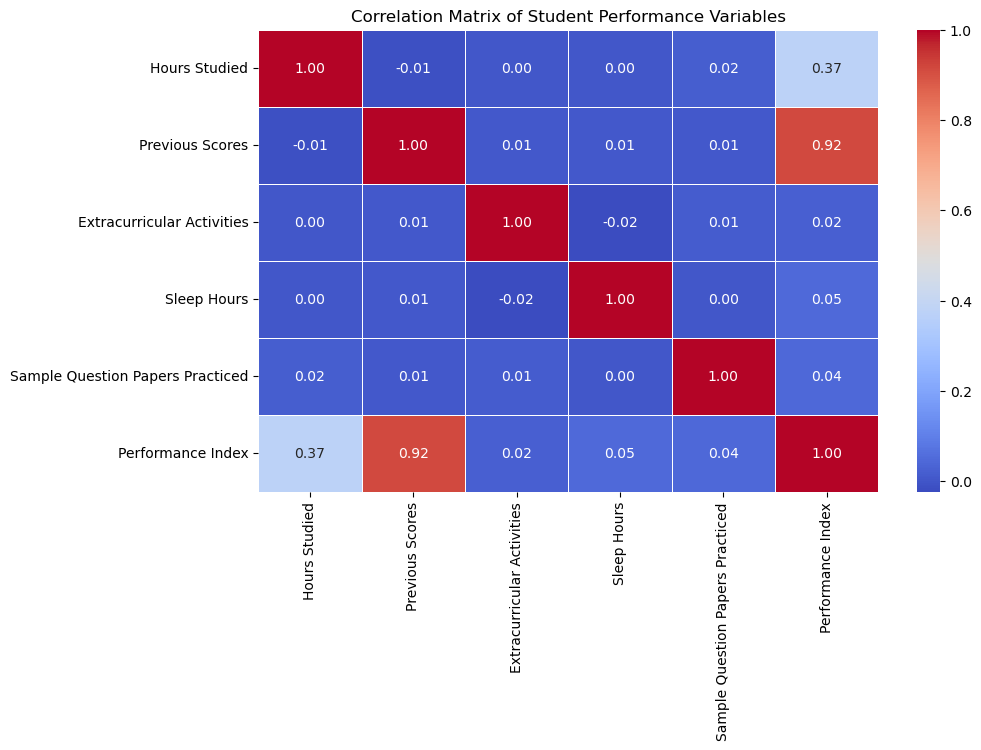

In [39]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Student Performance Variables')
plt.show()

## 3. Data Preparation

In [41]:
# Remove any leading/trailing whitespace and standardize the case for 'Extracurricular Activities'
df['Extracurricular Activities'] = df['Extracurricular Activities'].str.strip().str.capitalize()

In [42]:
# Encoding categorical data
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [43]:
# Feature selection
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [44]:
# Splitting 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print(f"Data successfully prepared.")
print(f"Training set: {X_train.shape} samples")
print(f"Testing set: {X_test.shape} samples")

Data successfully prepared.
Training set: (8000, 5) samples
Testing set: (2000, 5) samples


## 4. Modeling

In [46]:
# Initialze the model
model = LinearRegression()

In [47]:
# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
# Check the coefficient
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
display(coefficients)

,Coefficient
Hours Studied,2.852484
Previous Scores,1.016988
Extracurricular Activities,0.608617
Sleep Hours,0.476941
Sample Question Papers Practiced,0.191831


## 5. Evaluation

In [49]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [50]:
# Calculate how far off our predictions are on avg
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [51]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared: {r2:.3f}")

Mean Absolute Error (MAE): 1.61
Root Mean Squared Error (RMSE): 2.02
R-squared: 0.989


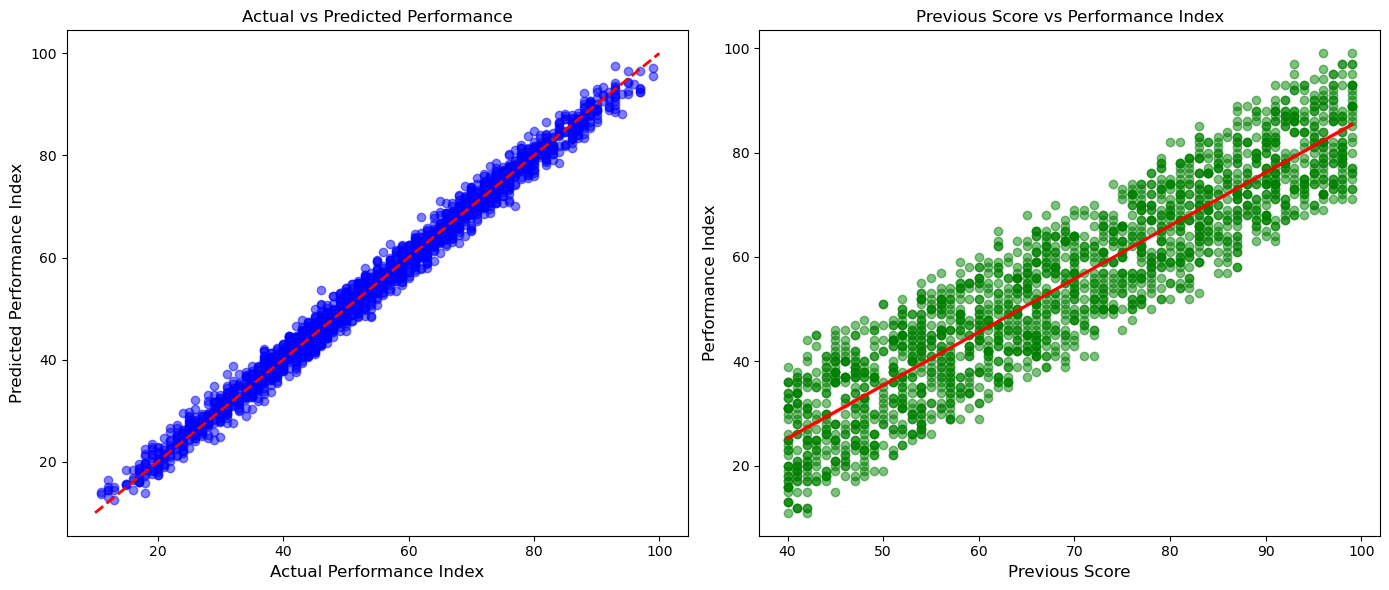

In [58]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Plot actual vs predicted values
axes[0].scatter(y_test, y_pred, color='blue', alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Performance')
axes[0].set_xlabel('Actual Performance Index', fontsize=12)
axes[0].set_ylabel('Predicted Performance Index', fontsize=12)

# 2. Regression Plot for the strongest feature
sns.regplot(x=X_test['Previous Scores'], y=y_test, ax=axes[1], 
            scatter_kws={'color': 'green', 'alpha': 0.5}, 
            line_kws={'color': 'red'})
axes[1].set_title('Previous Score vs Performance Index', fontsize=12)
axes[1].set_xlabel('Previous Score', fontsize=12)
axes[1].set_ylabel('Performance Index', fontsize=12)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

## 6. Deployment & Key Takeways

In [59]:
import joblib

# Save the trained model
joblib.dump(model, 'student_performance_model.pkl')
print("Model saved as 'student_performance_model.pkl'")

Model saved as 'student_performance_model.pkl'


## 7. Putting the model

In [60]:
# Load the save model
loaded_model = joblib.load('student_performance_model.pkl')

In [61]:
# Add new student
new_student_data = {
    'Hours Studied': 6,
    'Previous Scores': 80,
    'Extracurricular Activities': 1, # Remember, 1 means 'Yes'
    'Sleep Hours': 7,
    'Sample Question Papers Practiced': 4
}

In [62]:
# Convert the new student data into a DataFrame
new_student_df = pd.DataFrame([new_student_data])

print("New Student's Profile:")
display(new_student_df)

New Student's Profile:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,6,80,1,7,4


In [63]:
# Make predictions
predicted_performance = loaded_model.predict(new_student_df)

In [64]:
print(f"Predicted Performance Index for the new student: {predicted_performance[0]:.2f}")

Predicted Performance Index for the new student: 69.27
